**Disclaimer**: This notebook was generated using GitHub copilot. It contains analyses for temperature and humidity in early lifestage storms and compares their initial environment to their preconvective environment.

# Early-Life-Stage Environmental Profile Analysis

This notebook leaves the model-training parquet files unchanged. It joins lifestage at analysis time, keeps DCS rows with `life_stage < 0.1`, and extracts ERA5 profiles at the record nearest `deltatime = 0` and `deltatime = -6` hours.

In [44]:
import glob
import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, ScalarFormatter
import numpy as np
import pandas as pd
import xarray as xr

warnings.filterwarnings('ignore', category=RuntimeWarning)

## Configuration

Set `PROCESS_ALL_DATES = True` only after the sample validation cells complete successfully.

In [21]:
BASE_DIR = Path('/glade/u/home/malikah/Convection_trigger_function/model_training')
PARQUET_DIR = BASE_DIR / 'data'
ERA5_DIR = Path('/glade/work/addisus/GPM_TOOCAN_data/era5_select')
TOOCAN_DIR = Path('/glade/work/addisus/GPM_TOOCAN_data/gpm_select_toocan')
LIFESTAGE_DIR = Path('/glade/u/home/malikah/gpm_select_lifestage')
OUTPUT_DIR = BASE_DIR / 'analysis_outputs'

PROCESS_ALL_DATES = True
SAMPLE_DATE_COUNT = 3
EARLY_STAGE_LIMIT = 0.1
OFFSET_T0 = 0.0
OFFSET_TMINUS6 = -6.0
MAX_OFFSET_ERROR_HOURS = None

assert PARQUET_DIR.exists(), f'Missing parquet directory: {PARQUET_DIR}'
assert ERA5_DIR.exists(), f'Missing ERA5 directory: {ERA5_DIR}'
assert TOOCAN_DIR.exists(), f'Missing TOOCAN directory: {TOOCAN_DIR}'
assert LIFESTAGE_DIR.exists(), f'Missing lifestage directory: {LIFESTAGE_DIR}'

In [22]:
def date_from_name(path):
    name = Path(path).name
    date = name[:8]
    return date if len(date) == 8 and date.isdigit() else None

def files_by_date(directory, pattern='*'):
    result = {}
    for path in sorted(Path(directory).glob(pattern)):
        date = date_from_name(path)
        if date is not None:
            result.setdefault(date, []).append(path)
    return {date: paths[0] for date, paths in result.items()}

parquet_by_date = files_by_date(PARQUET_DIR, '*_df.parquet')
era5_by_date = files_by_date(ERA5_DIR, '*')
toocan_by_date = files_by_date(TOOCAN_DIR, '*')
stage_by_date = files_by_date(LIFESTAGE_DIR, '*_lifestage.nc')

common_dates = sorted(set(parquet_by_date) & set(era5_by_date) & set(toocan_by_date) & set(stage_by_date))
dates_to_process = common_dates if PROCESS_ALL_DATES else common_dates[:SAMPLE_DATE_COUNT]
print(f'Common dates: {len(common_dates)}')
print(f'Dates selected for this run: {dates_to_process}')

Common dates: 2472
Dates selected for this run: ['20140319', '20140320', '20140321', '20140322', '20140323', '20140324', '20140325', '20140326', '20140327', '20140328', '20140329', '20140330', '20140331', '20140401', '20140402', '20140403', '20140404', '20140405', '20140406', '20140407', '20140408', '20140409', '20140410', '20140411', '20140412', '20140413', '20140414', '20140415', '20140416', '20140417', '20140418', '20140419', '20140420', '20140421', '20140422', '20140423', '20140424', '20140425', '20140426', '20140427', '20140428', '20140429', '20140430', '20140501', '20140502', '20140503', '20140504', '20140505', '20140506', '20140507', '20140508', '20140509', '20140510', '20140511', '20140512', '20140513', '20140514', '20140515', '20140516', '20140517', '20140518', '20140519', '20140520', '20140521', '20140522', '20140523', '20140524', '20140525', '20140526', '20140527', '20140528', '20140529', '20140530', '20140531', '20140601', '20140602', '20140603', '20140604', '20140605', '20

## Load the existing training rows

`df_master` is read-only here. Lifestage is attached in a separate `df_analysis` dataframe.

In [23]:
df_master = pd.concat(
    [pd.read_parquet(parquet_by_date[date]) for date in common_dates],
    ignore_index=True,
)
key_columns = ['Date', 'Time_Step', 'DCS_ID']
missing_keys = [column for column in key_columns if column not in df_master.columns]
if missing_keys:
    raise KeyError(f'Missing required parquet columns: {missing_keys}')

df_master['Date'] = df_master['Date'].astype(str).str[:8]
df_master['Time_Step'] = df_master['Time_Step'].astype(int)
print(f'df_master shape: {df_master.shape}')
print(f"Unique dates in df_master: {df_master['Date'].nunique()}")

df_master shape: (125179, 66)
Unique dates in df_master: 2472


In [24]:
def valid_dcs_ids(values):
    values = np.asarray(values, dtype=float)
    return np.isfinite(values) & (values > 0)

def build_lifestage_lookup(date):
    with xr.open_dataset(stage_by_date[date]) as stage_ds, xr.open_dataset(toocan_by_date[date]) as toocan_ds:
        if 'life_stage' not in stage_ds:
            raise KeyError(f'{date}: no life_stage variable')
        if 'DCS_number' not in toocan_ds:
            raise KeyError(f'{date}: no DCS_number variable in TOOCAN file')

        stage = stage_ds['life_stage']
        dcs = toocan_ds['DCS_number']
        if stage.dims != ('nt', 'nsysmax'):
            raise ValueError(f'{date}: expected life_stage dims (nt, nsysmax), got {stage.dims}')
        if dcs.dims != ('nt', 'nsysmax'):
            raise ValueError(f'{date}: expected DCS_number dims (nt, nsysmax), got {dcs.dims}')
        if stage.shape != dcs.shape:
            raise ValueError(f'{date}: stage shape {stage.shape} does not match DCS shape {dcs.shape}')

        stage_values = stage.values.astype(float)
        dcs_values = dcs.values.astype(float)
        rows = []
        for time_step, system_slot in zip(*np.where(valid_dcs_ids(dcs_values))):
            rows.append({
                'Date': date,
                'Time_Step': int(time_step),
                'DCS_ID': dcs_values[time_step, system_slot],
                'system_slot': int(system_slot),
                'life_stage': stage_values[time_step, system_slot],
            })

    lookup = pd.DataFrame(rows)
    if lookup.empty:
        return lookup
    lookup['DCS_ID'] = lookup['DCS_ID'].astype(df_master['DCS_ID'].dtype)
    return lookup

lifestage_lookup = pd.concat(
    [build_lifestage_lookup(date) for date in dates_to_process],
    ignore_index=True,
)

duplicate_lookup_keys = lifestage_lookup.duplicated(key_columns, keep=False)
if duplicate_lookup_keys.any():
    raise ValueError('Lifestage lookup has duplicate Date/Time_Step/DCS_ID keys')

print(f'Lifestage lookup rows: {len(lifestage_lookup)}')
print(lifestage_lookup['life_stage'].describe())

Lifestage lookup rows: 133117
count    133117.000000
mean          0.483150
std           0.209845
min           0.000000
25%           0.333333
50%           0.482759
75%           0.625000
max           0.983051
Name: life_stage, dtype: float64


In [25]:
df_analysis = df_master[df_master['Date'].isin(dates_to_process)].merge(
    lifestage_lookup,
    on=key_columns,
    how='left',
    validate='many_to_one',
)

matched = df_analysis['life_stage'].notna()
print(f'Parquet rows in selected dates: {len(df_analysis)}')
print(f'Rows with lifestage: {matched.sum()} ({matched.mean():.1%})')

stage_valid = (
    df_analysis['life_stage'].notna()
    & np.isfinite(df_analysis['life_stage'])
    & (df_analysis['life_stage'] >= 0)
    & (df_analysis['life_stage'] <= 1)
)
df_early = df_analysis[stage_valid & (df_analysis['life_stage'] < EARLY_STAGE_LIMIT)].copy()

if df_early.empty:
    raise ValueError('No DCS rows satisfy the valid life_stage < 0.1 filter')

print(f'Early-life rows: {len(df_early)}')
print(f"Early-life distinct DCS IDs: {df_early['DCS_ID'].nunique()}")

Parquet rows in selected dates: 125179
Rows with lifestage: 125179 (100.0%)
Early-life rows: 4414
Early-life distinct DCS IDs: 4414


## ERA5 profile extraction at `t0` and `t0-6hr`

For each DCS row, `deltatime` is searched independently. The selected ERA5 record is the closest valid record to the requested offset.

A row is retained only when:

- the selected `t0` and `t0-6hr` ERA5 indices are different; and
- the selected `t0-6hr` record has `deltatime <= -3` hours, meaning it is at least three hours before `t0`.

Rejected rows are counted by rejection reason.

In [40]:
COMMON_PRESSURE_GRID = np.array(
    [1000, 925, 850, 700, 500, 400, 300, 250, 200, 150, 100, 70, 50],
    dtype=float,
)


def _valid_profile(values):
    values = np.asarray(values, dtype=float)
    valid = np.isfinite(values) & (values > -9000)
    if values.ndim == 1:
        return valid
    return np.any(valid, axis=tuple(range(1, values.ndim)))


def select_era5_index(ds_era5, time_step, system_slot, target_offset_hr):
    dt = np.asarray(ds_era5['deltatime'].values[:, time_step], dtype=float)
    dt[(~np.isfinite(dt)) | (dt <= -9000)] = np.nan

    availability = np.zeros(dt.shape, dtype=bool)
    if 'CAPE' in ds_era5:
        cape = np.asarray(ds_era5['CAPE'].values[:, 0, time_step, system_slot], dtype=float)
        availability |= np.isfinite(cape) & (cape > -9000)
    for variable in ['uprof', 'vprof', 'tprof', 'qprof']:
        if variable not in ds_era5:
            continue
        values = np.asarray(ds_era5[variable].values[:, ..., time_step, system_slot, :], dtype=float)
        availability |= _valid_profile(values)

    usable = np.isfinite(dt) & availability
    if not usable.any():
        return None, np.nan
    candidate_indices = np.where(usable)[0]
    selected = candidate_indices[np.argmin(np.abs(dt[candidate_indices] - target_offset_hr))]
    return int(selected), float(dt[selected])


def clean_profile(values):
    values = np.asarray(values, dtype=float)
    return np.where((values <= -9000) | ~np.isfinite(values), np.nan, values)


def extract_profile(ds_era5, variable, nc2_index, time_step, system_slot):
    data = ds_era5[variable]
    indexers = {'nc2': nc2_index, 'nt': time_step, 'nsysmax': system_slot}
    selected = data.isel({dim: indexers[dim] for dim in data.dims if dim in indexers})
    values = clean_profile(selected.values)
    if values.ndim > 1:
        values = np.nanmean(values, axis=tuple(range(values.ndim - 1)))
    return values


def pressure_levels(ds_era5, nc2_index, time_step, system_slot, profile_length):
    if 'plev' not in ds_era5:
        return np.arange(profile_length, dtype=float), False

    plev = ds_era5['plev']
    indexers = {
        dim: {
            'nc2': nc2_index,
            'nc1': 0,
            'nt': time_step,
            'nsysmax': system_slot,
        }[dim]
        for dim in plev.dims
        if dim in {'nc2', 'nc1', 'nt', 'nsysmax'}
    }
    values = np.asarray(plev.isel(indexers).values).squeeze()
    valid = (
        values.ndim == 1
        and len(values) == profile_length
        and np.all(np.isfinite(values))
        and np.all(values > 0)
    )
    if not valid:
        return np.arange(profile_length, dtype=float), False
    return values, True


def interpolate_to_common_pressure(profile, pressure, target_grid=COMMON_PRESSURE_GRID):
    profile = np.asarray(profile, dtype=float)
    pressure = np.asarray(pressure, dtype=float)
    valid = np.isfinite(profile) & np.isfinite(pressure) & (pressure > 0)
    if valid.sum() < 2:
        return np.full(target_grid.shape, np.nan, dtype=float)

    pressure_valid = pressure[valid]
    profile_valid = profile[valid]
    order = np.argsort(pressure_valid)
    pressure_sorted = pressure_valid[order]
    profile_sorted = profile_valid[order]
    pressure_sorted, unique_indices = np.unique(pressure_sorted, return_index=True)
    profile_sorted = profile_sorted[unique_indices]

    interpolated = np.full(target_grid.shape, np.nan, dtype=float)
    in_range = (target_grid >= pressure_sorted.min()) & (target_grid <= pressure_sorted.max())
    interpolated[in_range] = np.interp(
        target_grid[in_range], pressure_sorted, profile_sorted
    )
    return interpolated


def extract_early_profiles(df_rows):
    records = []
    rejection_counts = {
        'missing_snapshot': 0,
        'same_selected_era5_index': 0,
        'tminus6_not_at_least_3_hours_before_t0': 0,
        'offset_tolerance': 0,
        'profile_shape_mismatch': 0,
        'invalid_pressure_levels_retained_as_indices': 0,
    }
    for date, date_rows in df_rows.groupby('Date', sort=True):
        with xr.open_dataset(era5_by_date[date]) as ds_era5:
            for row in date_rows.itertuples(index=False):
                t = int(row.Time_Step)
                s = int(row.system_slot)
                t0_index, t0_delta = select_era5_index(ds_era5, t, s, OFFSET_T0)
                t6_index, t6_delta = select_era5_index(ds_era5, t, s, OFFSET_TMINUS6)
                if t0_index is None or t6_index is None:
                    rejection_counts['missing_snapshot'] += 1
                    continue
                if t0_index == t6_index:
                    rejection_counts['same_selected_era5_index'] += 1
                    continue
                if t6_delta > -3.0:
                    rejection_counts['tminus6_not_at_least_3_hours_before_t0'] += 1
                    continue
                if MAX_OFFSET_ERROR_HOURS is not None and (
                    abs(t0_delta - OFFSET_T0) > MAX_OFFSET_ERROR_HOURS
                    or abs(t6_delta - OFFSET_TMINUS6) > MAX_OFFSET_ERROR_HOURS
                ):
                    rejection_counts['offset_tolerance'] += 1
                    continue

                t0_profile = extract_profile(ds_era5, 'tprof', t0_index, t, s)
                t6_profile = extract_profile(ds_era5, 'tprof', t6_index, t, s)
                q0_profile = extract_profile(ds_era5, 'qprof', t0_index, t, s)
                q6_profile = extract_profile(ds_era5, 'qprof', t6_index, t, s)
                if not (len(t0_profile) == len(t6_profile) == len(q0_profile) == len(q6_profile)):
                    rejection_counts['profile_shape_mismatch'] += 1
                    continue

                pressure_t0, pressure_valid_t0 = pressure_levels(
                    ds_era5, t0_index, t, s, len(t0_profile)
                )
                pressure_t6, pressure_valid_t6 = pressure_levels(
                    ds_era5, t6_index, t, s, len(t6_profile)
                )
                pressure_valid = pressure_valid_t0 and pressure_valid_t6
                if not pressure_valid:
                    rejection_counts['invalid_pressure_levels_retained_as_indices'] += 1

                records.append({
                    'Date': date,
                    'Time_Step': t,
                    'DCS_ID': row.DCS_ID,
                    'life_stage': row.life_stage,
                    't0_delta_used': t0_delta,
                    'tminus6_delta_used': t6_delta,
                    'offset_separation_hours': abs(t0_delta - t6_delta),
                    'pressure_t0': pressure_t0,
                    'pressure_tminus6hr': pressure_t6,
                    'pressure_valid_t0': pressure_valid_t0,
                    'pressure_valid_tminus6hr': pressure_valid_t6,
                    'pressure_valid': pressure_valid,
                    'T_t0': t0_profile,
                    'T_tminus6hr': t6_profile,
                    'Qv_t0': q0_profile,
                    'Qv_tminus6hr': q6_profile,
                    'T_t0_common': interpolate_to_common_pressure(t0_profile, pressure_t0),
                    'T_tminus6hr_common': interpolate_to_common_pressure(t6_profile, pressure_t6),
                    'Qv_t0_common': interpolate_to_common_pressure(q0_profile, pressure_t0),
                    'Qv_tminus6hr_common': interpolate_to_common_pressure(q6_profile, pressure_t6),
                })
    records.sort(key=lambda record: record['offset_separation_hours'], reverse=True)
    print(f'Profile extraction rejections: {rejection_counts}')
    print(f'Rows with both valid native pressure arrays: {sum(record["pressure_valid"] for record in records)}')
    print(f'Rows with profile-index fallback for at least one snapshot: {sum(not record["pressure_valid"] for record in records)}')
    return records


profile_records = extract_early_profiles(df_early)
print(f'Rows with distinct t0 and t0-6hr ERA5 snapshots: {len(profile_records)}')
if not profile_records:
    raise ValueError('No early-life rows satisfy the distinct-index and t0-6hr <= -3 hour checks')

Profile extraction rejections: {'missing_snapshot': 0, 'same_selected_era5_index': 2306, 'tminus6_not_at_least_3_hours_before_t0': 0, 'offset_tolerance': 0, 'profile_shape_mismatch': 0, 'invalid_pressure_levels_retained_as_indices': 566}
Rows with both valid native pressure arrays: 1542
Rows with profile-index fallback for at least one snapshot: 566
Rows with distinct t0 and t0-6hr ERA5 snapshots: 2108


In [34]:
# Focused offset and pressure-level diagnostic for the first few early-life rows.
for date, date_rows in df_early.groupby('Date', sort=True):
    with xr.open_dataset(era5_by_date[date]) as ds_era5:
        for row in date_rows.head(3).itertuples(index=False):
            t = int(row.Time_Step)
            s = int(row.system_slot)
            t0_index, t0_delta = select_era5_index(ds_era5, t, s, OFFSET_T0)
            t6_index, t6_delta = select_era5_index(ds_era5, t, s, OFFSET_TMINUS6)
            plev_selected = np.asarray(ds_era5['plev'].isel(
                nc2=t0_index,
                nc1=0,
                nt=t,
                nsysmax=s,
            ).values, dtype=float).squeeze()
            print({
                'Date': date,
                'Time_Step': t,
                'DCS_ID': row.DCS_ID,
                't0': (t0_index, t0_delta),
                'tminus6': (t6_index, t6_delta),
                'plev_shape': plev_selected.shape,
                'plev_min': np.nanmin(plev_selected),
                'plev_max': np.nanmax(plev_selected),
                'plev_invalid_count': int((~np.isfinite(plev_selected) | (plev_selected <= 0)).sum()),
            })
        break

{'Date': '20140320', 'Time_Step': 4, 'DCS_ID': 1023653, 't0': (0, -2.0000000037252903), 'tminus6': (0, -2.0000000037252903), 'plev_shape': (15,), 'plev_min': np.float64(50.0), 'plev_max': np.float64(1015.414306640625), 'plev_invalid_count': 0}


In [41]:
def composite_profiles(records, variable):
    valid_pressure_records = [record for record in records if record['pressure_valid']]
    if not valid_pressure_records:
        return pd.DataFrame()
    rows = []
    for record in valid_pressure_records:
        for level, value in enumerate(np.asarray(record[variable], dtype=float)):
            rows.append({
                'Date': record['Date'],
                'DCS_ID': record['DCS_ID'],
                'pressure': COMMON_PRESSURE_GRID[level],
                'level_index': level,
                'value': value,
            })
    long = pd.DataFrame(rows).dropna(subset=['value'])
    summary = long.groupby(['level_index', 'pressure'], as_index=False).agg(
        mean=('value', 'mean'),
        std=('value', 'std'),
        count=('value', 'count'),
        storms=('DCS_ID', 'nunique'),
    )
    summary['sem'] = summary['std'] / np.sqrt(summary['count'])
    summary['ci95'] = 1.96 * summary['sem']
    return summary


temperature_t0 = composite_profiles(profile_records, 'T_t0_common')
temperature_tminus6 = composite_profiles(profile_records, 'T_tminus6hr_common')
qv_t0 = composite_profiles(profile_records, 'Qv_t0_common')
qv_tminus6 = composite_profiles(profile_records, 'Qv_tminus6hr_common')


def paired_difference(records, variable_t0, variable_t6):
    valid_pressure_records = [record for record in records if record['pressure_valid']]
    rows = []
    for record in valid_pressure_records:
        values = np.asarray(record[variable_t0]) - np.asarray(record[variable_t6])
        for level, value in enumerate(values):
            rows.append({
                'Date': record['Date'],
                'DCS_ID': record['DCS_ID'],
                'pressure': COMMON_PRESSURE_GRID[level],
                'level_index': level,
                'value': value,
            })
    if not rows:
        return pd.DataFrame()
    long = pd.DataFrame(rows).replace([np.inf, -np.inf], np.nan).dropna(subset=['value'])
    summary = long.groupby(['level_index', 'pressure'], as_index=False).agg(
        mean=('value', 'mean'),
        std=('value', 'std'),
        count=('value', 'count'),
        storms=('DCS_ID', 'nunique'),
    )
    summary['sem'] = summary['std'] / np.sqrt(summary['count'])
    summary['ci95'] = 1.96 * summary['sem']
    return summary


temperature_difference = paired_difference(profile_records, 'T_t0_common', 'T_tminus6hr_common')
qv_difference = paired_difference(profile_records, 'Qv_t0_common', 'Qv_tminus6hr_common')
temperature_difference.head()

,level_index,pressure,mean,std,count,storms,sem,ci95
0,0,1000.0,-0.193864,1.011172,1542,1542,0.025750,0.050471
1,1,925.0,-0.067799,0.651026,1542,1542,0.016579,0.032495
2,2,850.0,-0.078967,0.669958,1542,1542,0.017061,0.033440
3,3,700.0,-0.079579,0.634201,1542,1542,0.016150,0.031655
4,4,500.0,-0.015763,0.612235,1542,1542,0.015591,0.030559


Plotting profile 1/5: Date=20140327, Time_Step=20, DCS_ID=1021455, offset separation=6 hours, pressure_valid_t0=True, pressure_valid_tminus6hr=True


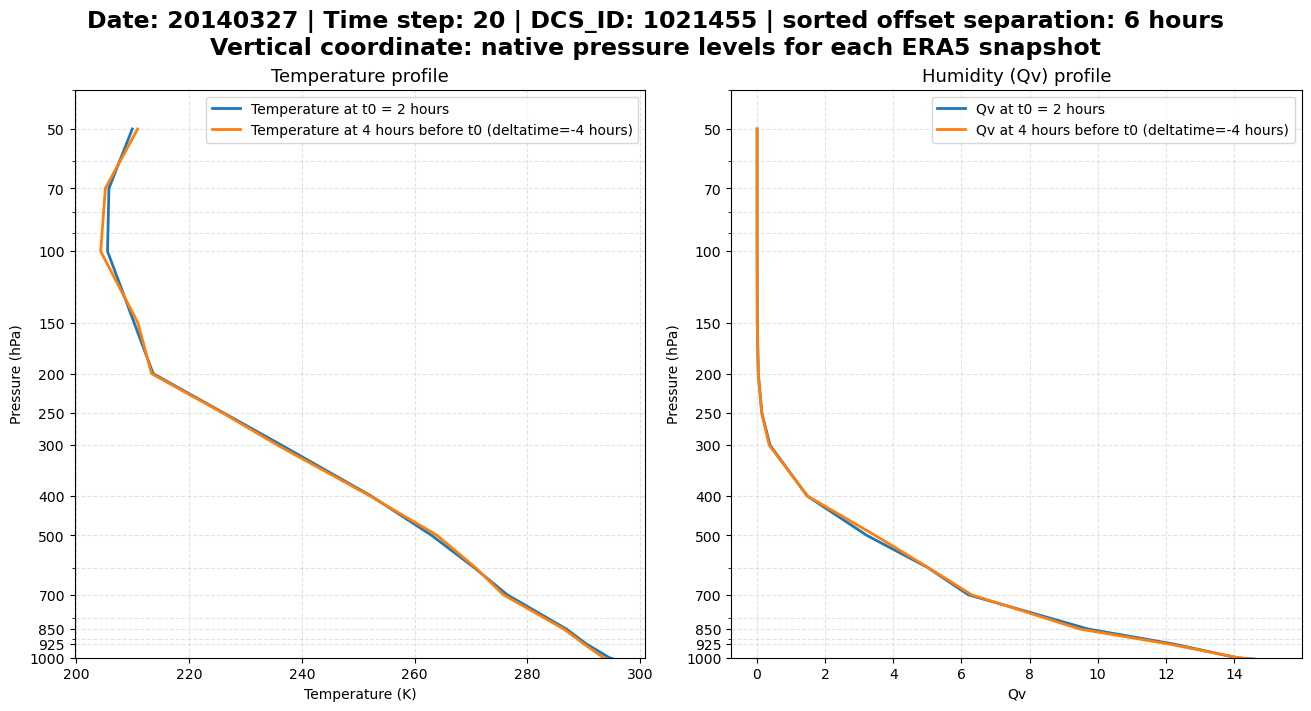

Plotting profile 2/5: Date=20140327, Time_Step=21, DCS_ID=1009180, offset separation=6 hours, pressure_valid_t0=True, pressure_valid_tminus6hr=True


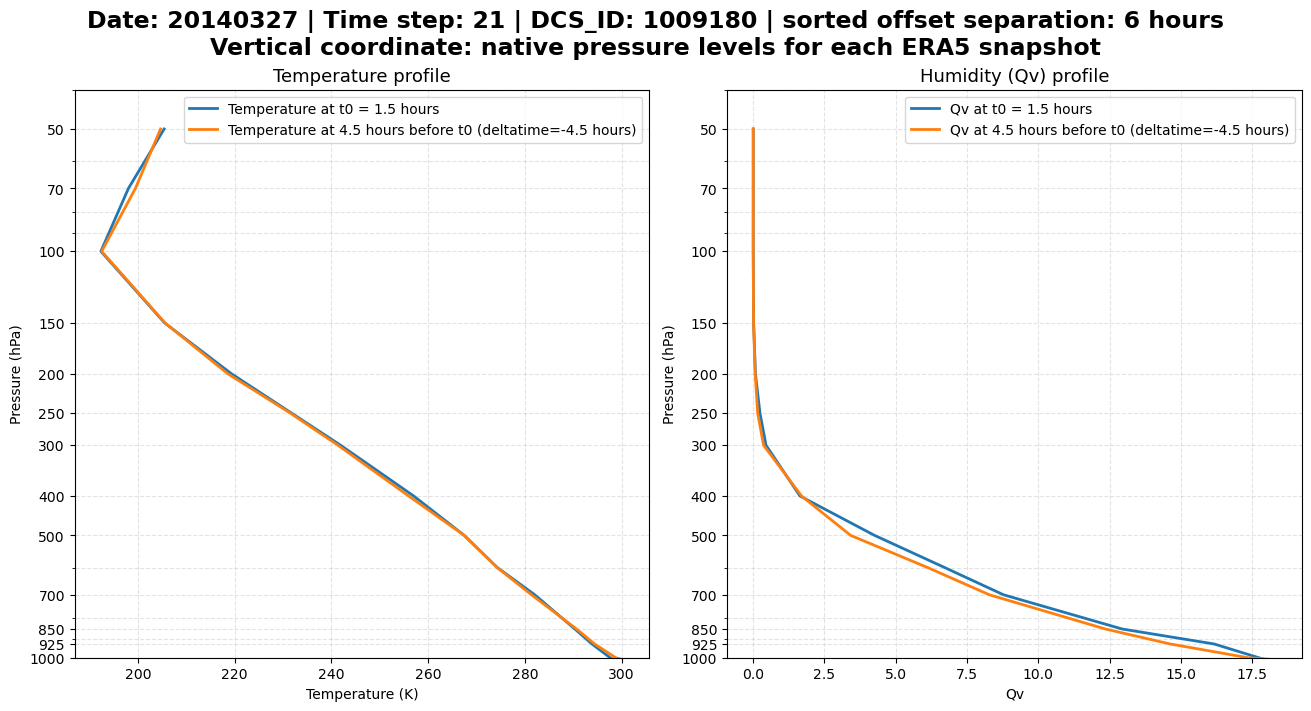

Plotting profile 3/5: Date=20140327, Time_Step=33, DCS_ID=25821501, offset separation=6 hours, pressure_valid_t0=False, pressure_valid_tminus6hr=False


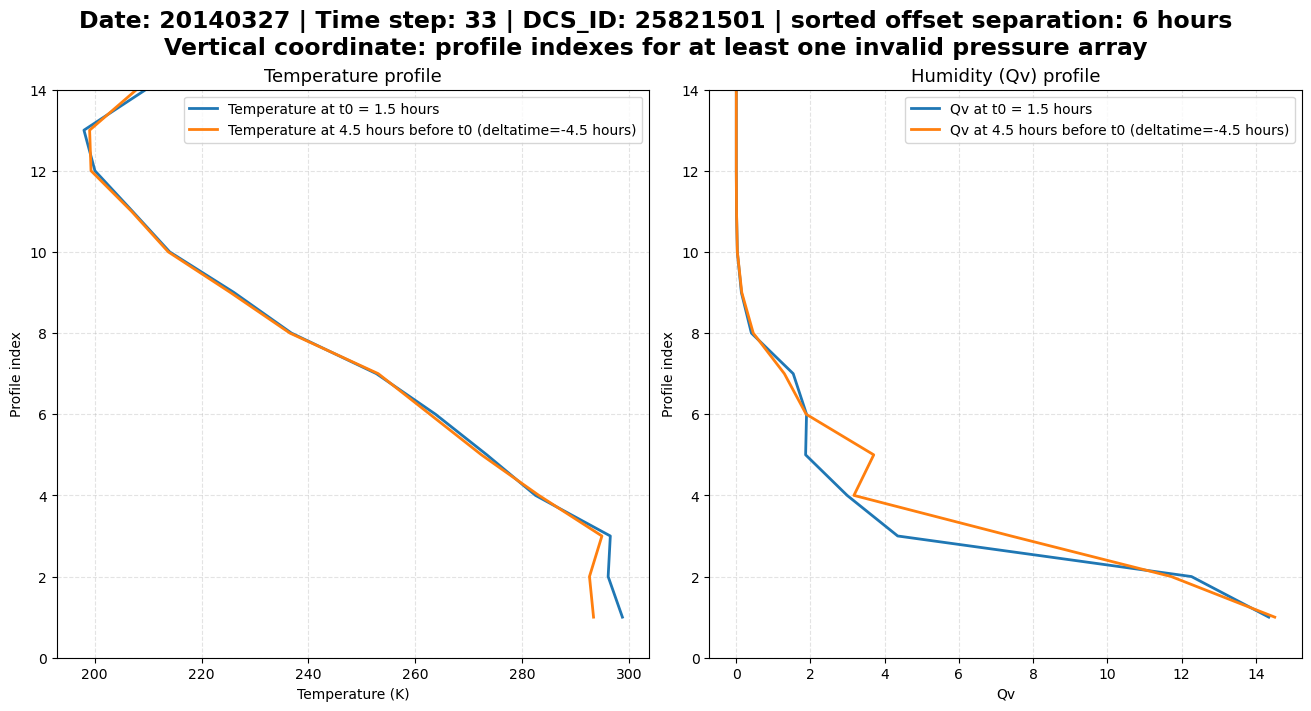

Plotting profile 4/5: Date=20140328, Time_Step=10, DCS_ID=5956434, offset separation=6 hours, pressure_valid_t0=True, pressure_valid_tminus6hr=True


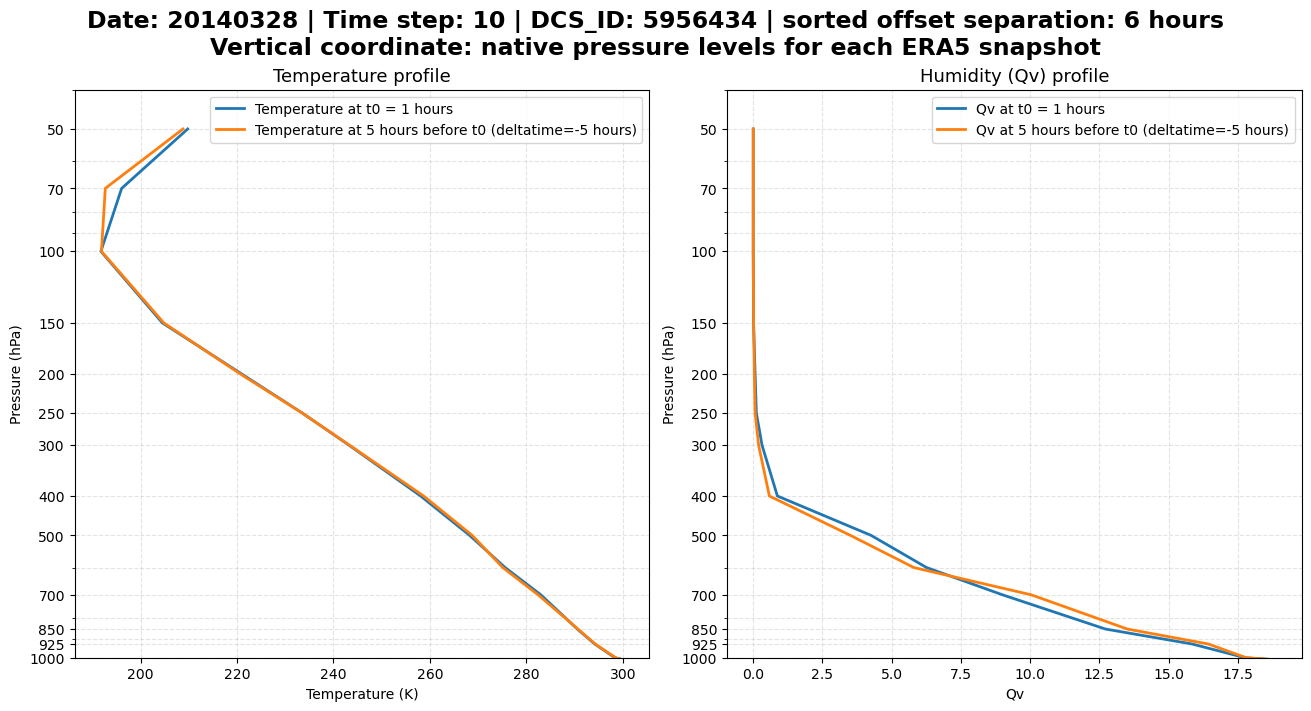

Plotting profile 5/5: Date=20140328, Time_Step=11, DCS_ID=20601672, offset separation=6 hours, pressure_valid_t0=True, pressure_valid_tminus6hr=True


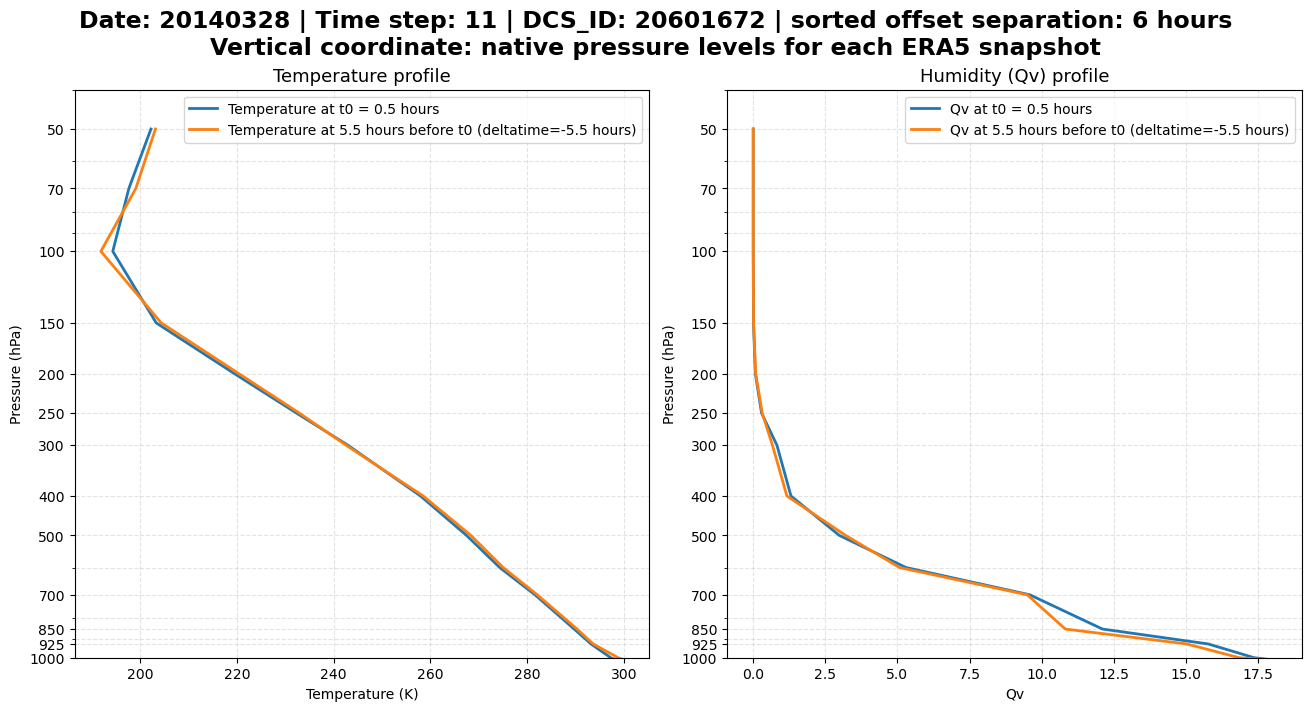

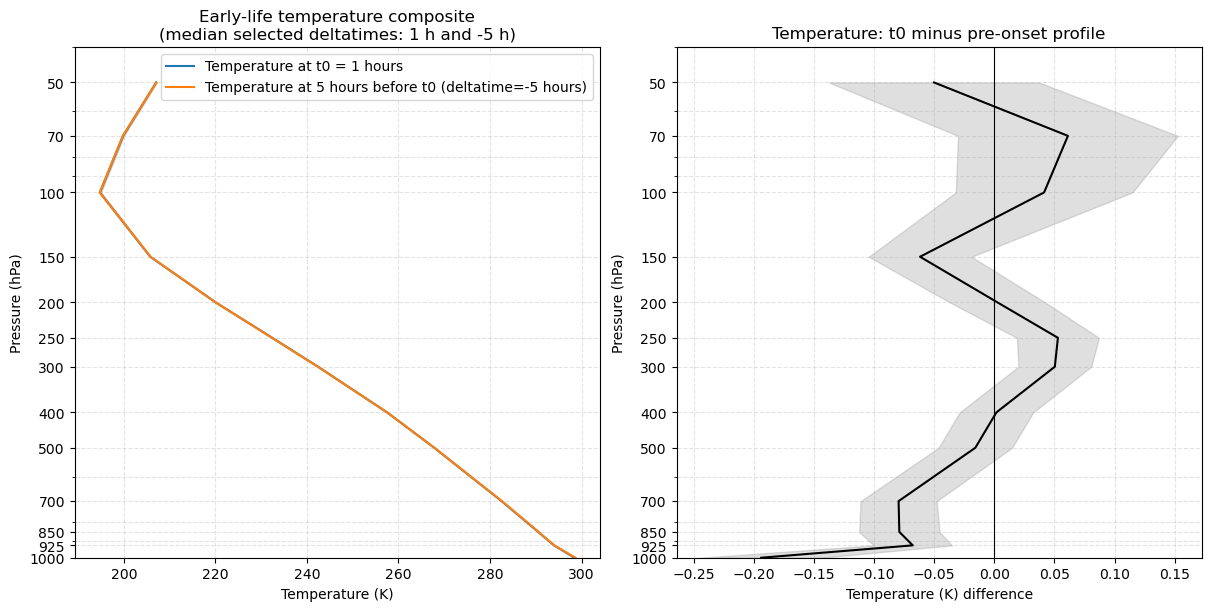

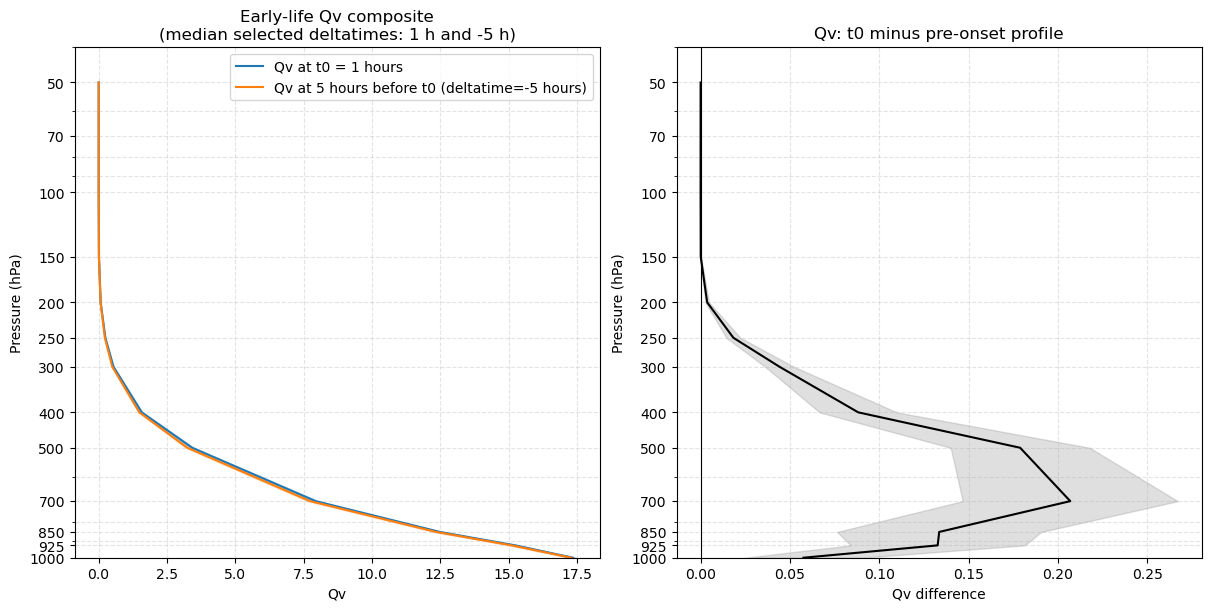

In [45]:
def format_hours(hours):
    return f'{float(hours):g}'


def t0_profile_label(variable_name, offset_hours):
    return f'{variable_name} at t0 = {format_hours(offset_hours)} hours'


def pre_onset_profile_label(variable_name, offset_hours):
    hours_before_t0 = abs(float(offset_hours))
    return (
        f'{variable_name} at {format_hours(hours_before_t0)} hours before t0 '
        f'(deltatime={format_hours(offset_hours)} hours)'
    )


def format_pressure_axis(ax, pressure_valid):
    if pressure_valid:
        ax.set_yscale('log')
        ax.set_ylim(1000, 40)
        pressure_ticks = [1000, 925, 850, 700, 500, 400, 300, 250, 200, 150, 100, 70, 50]
        ax.yaxis.set_major_locator(FixedLocator(pressure_ticks))
        scalar_formatter = ScalarFormatter()
        scalar_formatter.set_scientific(False)
        scalar_formatter.set_useOffset(False)
        ax.yaxis.set_major_formatter(scalar_formatter)
        ax.set_ylabel('Pressure (hPa)')
        ax.grid(True, which='both', linestyle='--', alpha=0.35)
    else:
        ax.set_ylabel('Profile index')
        ax.set_ylim(0, 14)
        ax.grid(True, linestyle='--', alpha=0.35)


def plot_comparison(
    t0_summary,
    t6_summary,
    difference_summary,
    title,
    xlabel,
    variable_name,
    t0_offset_hours,
    tminus6_offset_hours,
):
    fig, axes = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)
    t0_label = t0_profile_label(variable_name, t0_offset_hours)
    t6_label = pre_onset_profile_label(variable_name, tminus6_offset_hours)
    for summary, label, color in [
        (t0_summary, t0_label, 'tab:blue'),
        (t6_summary, t6_label, 'tab:orange'),
    ]:
        axes[0].plot(summary['mean'], summary['pressure'], label=label, color=color)
        axes[0].fill_betweenx(
            summary['pressure'],
            summary['mean'] - summary['ci95'],
            summary['mean'] + summary['ci95'],
            color=color,
            alpha=0.18,
        )
    axes[0].set_title(
        f'{title}\n(median selected deltatimes: '
        f'{format_hours(t0_offset_hours)} h and {format_hours(tminus6_offset_hours)} h)'
    )
    axes[0].set_xlabel(xlabel)
    format_pressure_axis(axes[0], pressure_valid=True)
    axes[0].legend()
    axes[1].plot(difference_summary['mean'], difference_summary['pressure'], color='black')
    axes[1].fill_betweenx(
        difference_summary['pressure'],
        difference_summary['mean'] - difference_summary['ci95'],
        difference_summary['mean'] + difference_summary['ci95'],
        color='gray',
        alpha=0.25,
    )
    axes[1].axvline(0, color='black', linewidth=0.8)
    axes[1].set_title(f'{variable_name}: t0 minus pre-onset profile')
    axes[1].set_xlabel(f'{xlabel} difference')
    format_pressure_axis(axes[1], pressure_valid=True)
    return fig, axes


def plot_profile_record(record):
    if record['pressure_valid']:
        t0_vertical = record['pressure_t0']
        t6_vertical = record['pressure_tminus6hr']
        axis_label = 'native pressure levels for each ERA5 snapshot'
    else:
        t0_vertical = np.arange(len(record['T_t0']), dtype=float)
        t6_vertical = np.arange(len(record['T_tminus6hr']), dtype=float)
        axis_label = 'profile indexes for at least one invalid pressure array'

    metadata_title = (
        f"Date: {record['Date']} | Time step: {record['Time_Step']} | "
        f"DCS_ID: {record['DCS_ID']} | sorted offset separation: "
        f"{record['offset_separation_hours']:g} hours\n"
        f"Vertical coordinate: {axis_label}"
    )
    fig, axes = plt.subplots(1, 2, figsize=(13, 7), constrained_layout=True)
    fig.suptitle(metadata_title, fontsize=17, fontweight='bold')

    axes[0].plot(
        record['T_t0'], t0_vertical, color='tab:blue', linewidth=2,
        label=t0_profile_label('Temperature', record['t0_delta_used']),
    )
    axes[0].plot(
        record['T_tminus6hr'], t6_vertical, color='tab:orange', linewidth=2,
        label=pre_onset_profile_label('Temperature', record['tminus6_delta_used']),
    )
    axes[0].set_title('Temperature profile', fontsize=13)
    axes[0].set_xlabel('Temperature (K)')
    format_pressure_axis(axes[0], record['pressure_valid'])
    axes[0].legend()

    axes[1].plot(
        record['Qv_t0'], t0_vertical, color='tab:blue', linewidth=2,
        label=t0_profile_label('Qv', record['t0_delta_used']),
    )
    axes[1].plot(
        record['Qv_tminus6hr'], t6_vertical, color='tab:orange', linewidth=2,
        label=pre_onset_profile_label('Qv', record['tminus6_delta_used']),
    )
    axes[1].set_title('Humidity (Qv) profile', fontsize=13)
    axes[1].set_xlabel('Qv')
    format_pressure_axis(axes[1], record['pressure_valid'])
    axes[1].legend()
    return fig, axes


for profile_number, record in enumerate(profile_records[:5], start=1):
    print(
        f'Plotting profile {profile_number}/5: Date={record["Date"]}, '
        f'Time_Step={record["Time_Step"]}, DCS_ID={record["DCS_ID"]}, '
        f'offset separation={record["offset_separation_hours"]:g} hours, '
        f'pressure_valid_t0={record["pressure_valid_t0"]}, '
        f'pressure_valid_tminus6hr={record["pressure_valid_tminus6hr"]}'
    )
    plot_profile_record(record)
    plt.show()

valid_profile_records = [record for record in profile_records if record['pressure_valid']]
if valid_profile_records:
    selected_t0_offset = float(np.nanmedian([record['t0_delta_used'] for record in valid_profile_records]))
    selected_tminus6_offset = float(np.nanmedian([record['tminus6_delta_used'] for record in valid_profile_records]))
    plot_comparison(
        temperature_t0, temperature_tminus6, temperature_difference,
        'Early-life temperature composite', 'Temperature (K)', 'Temperature',
        selected_t0_offset, selected_tminus6_offset,
    )
    plt.show()
    plot_comparison(
        qv_t0, qv_tminus6, qv_difference,
        'Early-life Qv composite', 'Qv', 'Qv',
        selected_t0_offset, selected_tminus6_offset,
    )
    plt.show()

In [43]:
# Save the derived early-life analysis products. Existing training parquet files are untouched.
OUTPUT_DIR.mkdir(exist_ok=True)

native_rows = []
common_rows = []
for record_rank, record in enumerate(profile_records, start=1):
    native_length = len(record['T_t0'])
    for level in range(native_length):
        native_rows.append({
            'sorted_profile_rank': record_rank,
            'Date': record['Date'],
            'Time_Step': record['Time_Step'],
            'DCS_ID': record['DCS_ID'],
            'life_stage': record['life_stage'],
            'level_index': level,
            'pressure_t0_hPa': record['pressure_t0'][level],
            'pressure_tminus6hr_hPa': record['pressure_tminus6hr'][level],
            'pressure_valid_t0': record['pressure_valid_t0'],
            'pressure_valid_tminus6hr': record['pressure_valid_tminus6hr'],
            't0_delta_used': record['t0_delta_used'],
            'tminus6_delta_used': record['tminus6_delta_used'],
            'offset_separation_hours': record['offset_separation_hours'],
            'T_t0': record['T_t0'][level],
            'T_tminus6hr': record['T_tminus6hr'][level],
            'Qv_t0': record['Qv_t0'][level],
            'Qv_tminus6hr': record['Qv_tminus6hr'][level],
        })

    for level, pressure in enumerate(COMMON_PRESSURE_GRID):
        common_rows.append({
            'sorted_profile_rank': record_rank,
            'Date': record['Date'],
            'Time_Step': record['Time_Step'],
            'DCS_ID': record['DCS_ID'],
            'life_stage': record['life_stage'],
            'pressure_hPa': pressure,
            'level_index': level,
            'pressure_valid': record['pressure_valid'],
            't0_delta_used': record['t0_delta_used'],
            'tminus6_delta_used': record['tminus6_delta_used'],
            'offset_separation_hours': record['offset_separation_hours'],
            'T_t0': record['T_t0_common'][level],
            'T_tminus6hr': record['T_tminus6hr_common'][level],
            'Qv_t0': record['Qv_t0_common'][level],
            'Qv_tminus6hr': record['Qv_tminus6hr_common'][level],
        })

analysis_product = pd.DataFrame(native_rows)
common_grid_product = pd.DataFrame(common_rows)
analysis_path = OUTPUT_DIR / 'early_lifestage_profiles.parquet'
common_grid_path = OUTPUT_DIR / 'early_lifestage_profiles_common_pressure_grid.parquet'
analysis_product.to_parquet(analysis_path, index=False)
common_grid_product.to_parquet(common_grid_path, index=False)
print(f'Saved native-coordinate rows to {analysis_path}')
print(f'Saved common-grid rows to {common_grid_path}')
print('Records are sorted descending by offset_separation_hours.')

Saved native-coordinate rows to /glade/u/home/malikah/Convection_trigger_function/model_training/analysis_outputs/early_lifestage_profiles.parquet
Saved common-grid rows to /glade/u/home/malikah/Convection_trigger_function/model_training/analysis_outputs/early_lifestage_profiles_common_pressure_grid.parquet
Records are sorted descending by offset_separation_hours.
